# 03  -  Business KPIsThe three analyses mandated by Section 5 of the brief: **monthly sales trends**,**top-selling products**, and **customer segmentation by purchase behaviour**.Each is cross-read against delivery performance, so the report tells one story ratherthan four unrelated ones. All definitions come from the marts layer and are documentedin `docs/metric_dictionary.md`; nothing is redefined in this notebook.

In [1]:
# warehouse.py lives at the repository root so the notebooks and the Streamlit
# dashboard share one definition of which datasets to read. Walk up from the
# working directory to find it, so the notebook runs the same whether it is
# opened in Jupyter or executed headless by `make analyse`.
import sys, pathlib
_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "warehouse.py").exists())
sys.path.insert(0, str(_root))

import pandas as pd
import matplotlib.pyplot as plt

from warehouse import q, marts, staging, raw, style_charts, describe_connection, SNAPSHOT_DATE

style_charts()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

print(describe_connection())

/Users/timkoo/miniconda3/envs/bd-m2-g7/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.6.0)/charset_normalizer (3.5.1) doesn't match a supported version!
  warnings.warn(


project=olist-group7  location=US  target=dev
marts dataset=dbt_TK_marts
analytical snapshot date=2018-10-17


## 1. Monthly sales trend**Definition.** Revenue = `sum(item_price)`. Freight is reported separately and neverfolded into revenue. Order count is distinct orders. `canceled` and `unavailable`statuses are excluded. Partial edge months are annotated, not silently dropped.

/Users/timkoo/miniconda3/envs/bd-m2-g7/lib/python3.11/site-packages/google/cloud/bigquery/client.py:613: UserWarning: Cannot create BigQuery Storage client, the dependency google-cloud-bigquery-storage is not installed.
  warnings.warn(


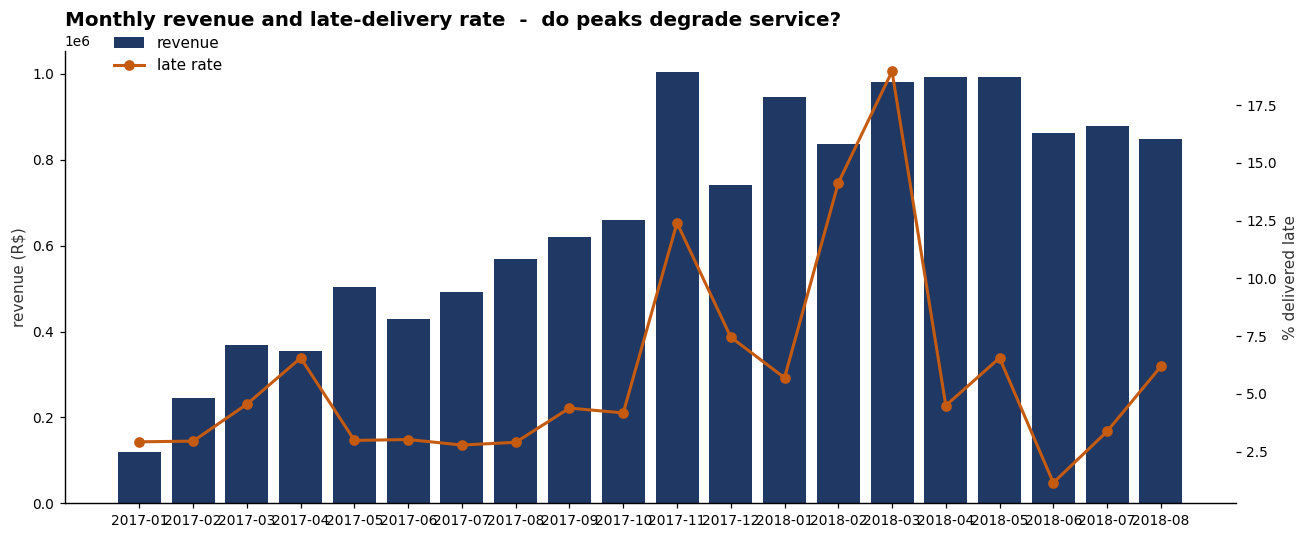

Excluded as partial months (annotated, not hidden):


,year_month,order_count,revenue
0,2016-09,2,207.86
1,2016-10,293,44507.30
2,2016-12,1,10.90
23,2018-09,1,145.00


In [2]:
sales = q(f"""
    select
        year_month, month_start_date, is_in_analysis_window,
        revenue, freight, order_count, items_sold, active_customers,
        avg_order_value, revenue_mom_growth,
        late_rate, median_delivery_days, avg_review_score
    from {marts('agg_monthly_sales')}
    order by month_start_date
""")

usable = sales[sales.is_in_analysis_window & (sales.order_count >= 500)]

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(usable.year_month, usable.revenue, color="#1f3864", label="revenue")
ax1.set_ylabel("revenue (R$)"); ax1.grid(False)
ax2 = ax1.twinx()
ax2.plot(usable.year_month, usable.late_rate * 100, color="#c55a11",
         marker="o", linewidth=2, label="late rate")
ax2.set_ylabel("% delivered late"); ax2.grid(False)
ax1.set_title("Monthly revenue and late-delivery rate  -  do peaks degrade service?")
plt.xticks(rotation=90)
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.95))
plt.tight_layout(); plt.show()

print("Excluded as partial months (annotated, not hidden):")
display(sales[~sales.index.isin(usable.index)][["year_month", "order_count", "revenue"]])

In [3]:
print(f"Total revenue in window : R$ {usable.revenue.sum():,.0f}")
print(f"Total orders            : {usable.order_count.sum():,}")
print(f"Average order value     : R$ {usable.revenue.sum() / usable.order_count.sum():,.2f}")
print()
print("Strongest months:")
display(usable.nlargest(5, "revenue")[["year_month", "revenue", "order_count", "avg_order_value", "late_rate"]])
print("Weakest months in the window:")
display(usable.nsmallest(5, "revenue")[["year_month", "revenue", "order_count", "avg_order_value", "late_rate"]])

Total revenue in window : R$ 13,449,530
Total orders            : 97,910
Average order value     : R$ 137.37

Strongest months:


,year_month,revenue,order_count,avg_order_value,late_rate
13,2017-11,1003862.14,7423,135.24,0.1240
18,2018-04,993592.98,6919,143.60,0.0450
19,2018-05,992871.75,6833,145.31,0.0656
17,2018-03,981051.06,7168,136.87,0.1896
15,2018-01,945456.29,7187,131.55,0.0570


Weakest months in the window:


,year_month,revenue,order_count,avg_order_value,late_rate
3,2017-01,120098.27,787,152.60,0.0293
4,2017-02,244959.35,1718,142.58,0.0296
6,2017-04,353842.98,2377,148.86,0.0656
5,2017-03,368341.32,2617,140.75,0.0456
8,2017-06,429916.61,3205,134.14,0.0303


In [4]:
# Does service quality degrade when volume peaks? A direct answer, not an impression.
corr = usable[["order_count", "late_rate", "median_delivery_days"]].corr()
display(corr.round(3))
print("Correlation between monthly order volume and late rate:",
      round(usable.order_count.corr(usable.late_rate), 3))
print("Positive means peaks strain fulfilment. This is descriptive, not causal.")

,order_count,late_rate,median_delivery_days
order_count,1.000,0.515,-0.001
late_rate,0.515,1.000,0.668
median_delivery_days,-0.001,0.668,1.000


Correlation between monthly order volume and late rate: 0.515
Positive means peaks strain fulfilment. This is descriptive, not causal.


## 2. Top-selling products**Definition.** Revenue, units and distinct orders are read **together**. Ranking onrevenue alone flatters high-price, low-volume categories and hides real volumedrivers. Each category also carries its delivery profile.

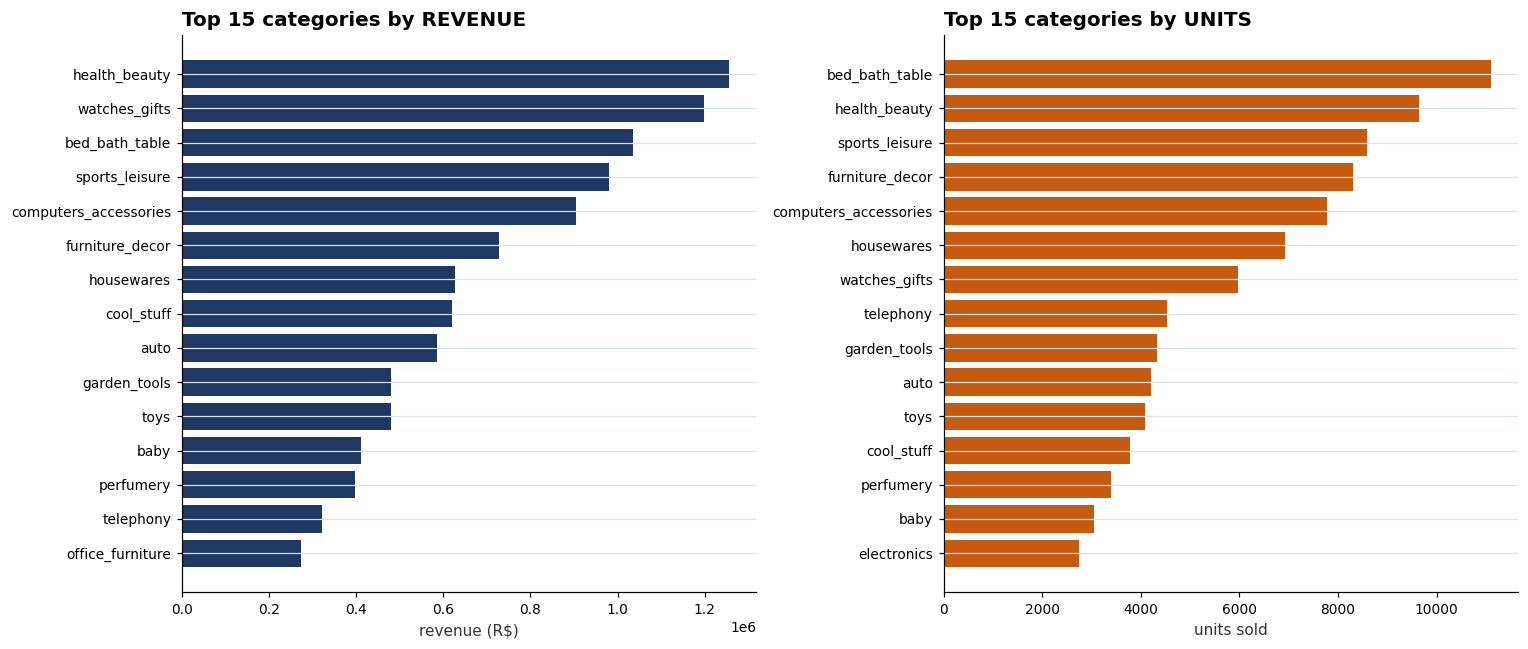

Categories that rank very differently on revenue vs volume:


,product_category,revenue_rank,volume_rank,revenue,units_sold,avg_item_price
16,computers,17,47,222963.13,203,1098.34
35,small_appliances_home_oven_and_coffee,36,55,47445.71,76,624.29
26,home_appliances_2,27,43,110649.74,235,470.85
29,agro_industry_and_commerce,30,45,72530.47,212,342.12
46,drinks,47,32,22378.71,378,59.20
51,food_drink,52,38,15119.48,276,54.78
41,food,42,29,29243.51,509,57.45
37,books_general_interest,38,28,45622.29,546,83.56


In [5]:
products = q(f"""
    select
        product_category, revenue, units_sold, order_count, distinct_products,
        avg_item_price, revenue_share, revenue_rank, volume_rank,
        late_rate, median_delivery_days, avg_review_score,
        is_high_value_poor_delivery
    from {marts('agg_product_performance')}
    where is_reportable
    order by revenue desc
""")

top15 = products.head(15)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.barh(top15.product_category[::-1], top15.revenue[::-1], color="#1f3864")
ax1.set_title("Top 15 categories by REVENUE"); ax1.set_xlabel("revenue (R$)")
byvol = products.nlargest(15, "units_sold")
ax2.barh(byvol.product_category[::-1], byvol.units_sold[::-1], color="#c55a11")
ax2.set_title("Top 15 categories by UNITS"); ax2.set_xlabel("units sold")
plt.tight_layout(); plt.show()

print("Categories that rank very differently on revenue vs volume:")
divergent = products.assign(rank_gap=(products.revenue_rank - products.volume_rank).abs())
display(divergent.nlargest(8, "rank_gap")
        [["product_category", "revenue_rank", "volume_rank", "revenue", "units_sold", "avg_item_price"]])

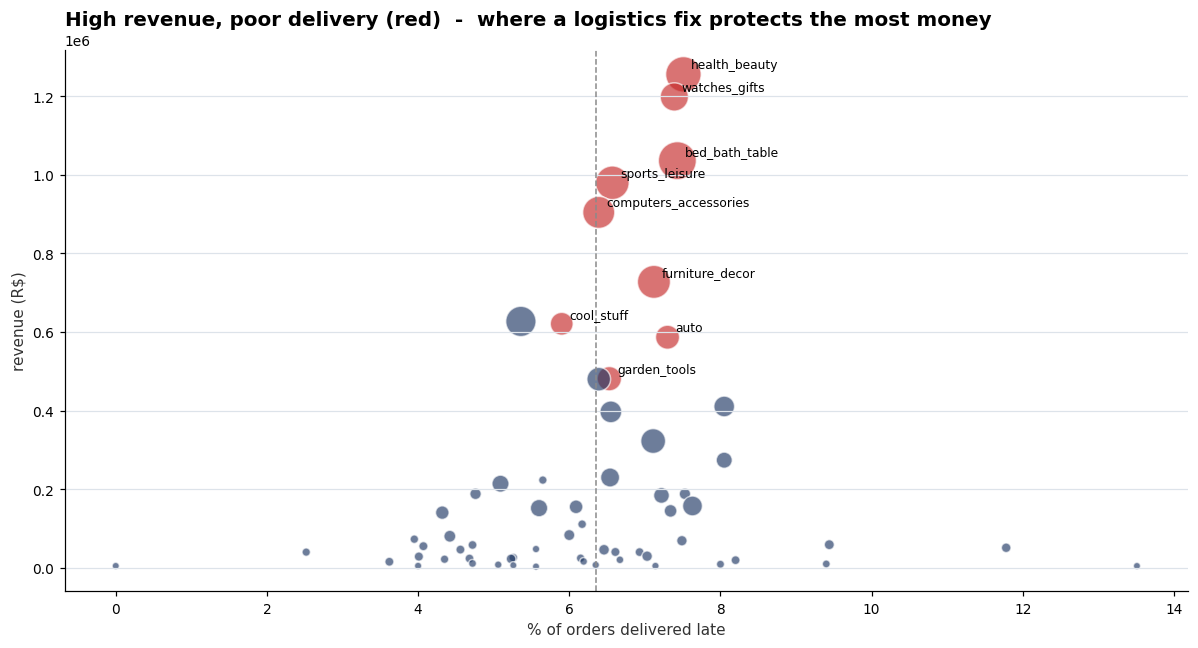

,product_category,revenue,revenue_rank,late_rate,median_delivery_days,avg_review_score
0,health_beauty,1255695.13,1,0.0751,9.50,4.230
1,watches_gifts,1198185.21,2,0.0739,10.33,4.121
2,bed_bath_table,1035964.06,3,0.0743,10.71,3.999
3,sports_leisure,979740.92,4,0.0657,10.08,4.228
4,computers_accessories,904322.02,5,0.0639,11.08,4.082
5,furniture_decor,727465.05,6,0.0712,10.83,4.059
7,cool_stuff,620770.49,8,0.0590,10.38,4.218
8,auto,586585.73,9,0.0730,9.71,4.145
9,garden_tools,481009.94,10,0.0653,11.63,4.180


In [6]:
# The cross-read that only exists because delivery and sales share one warehouse.
fig, ax = plt.subplots(figsize=(11, 6))
sizes = (products.units_sold / products.units_sold.max() * 600) + 20
ax.scatter(products.late_rate * 100, products.revenue, s=sizes,
           c=["#c62828" if f else "#1f3864" for f in products.is_high_value_poor_delivery],
           alpha=0.65, edgecolors="white")
ax.axvline(products.late_rate.median() * 100, color="#8a8a8a", linestyle="--", linewidth=1)
ax.set_xlabel("% of orders delivered late"); ax.set_ylabel("revenue (R$)")
ax.set_title("High revenue, poor delivery (red)  -  where a logistics fix protects the most money")
for _, r in products[products.is_high_value_poor_delivery].iterrows():
    ax.annotate(r.product_category, (r.late_rate * 100, r.revenue), fontsize=8,
                xytext=(5, 4), textcoords="offset points")
plt.tight_layout(); plt.show()

display(products[products.is_high_value_poor_delivery]
        [["product_category", "revenue", "revenue_rank", "late_rate", "median_delivery_days", "avg_review_score"]])

## 3. Customer segmentation (RFM)**Definition.** Grain is `customer_unique_id`, the person. Recency is measured againstthe dataset snapshot date, never today. Frequency is distinct orders. Monetary istotal revenue. Each segment is cross-tabulated with its delivery experience.

Recency baseline (dataset snapshot date): 2018-10-17


,rfm_segment,customers,avg_recency_days,avg_frequency,avg_monetary,total_revenue,revenue_share,avg_late_rate,avg_review_score,high_value_served_late
0,1. Champions,15689,141.0,1.07,271.55,4260297.0,0.3157,0.0661,4.12,1072
1,"2. High value, recent",7563,269.0,1.07,253.90,1920213.0,0.1423,0.1155,3.86,891
2,"3. At risk, high value",14744,444.0,1.05,279.98,4128094.0,0.3059,0.0610,4.08,905
3,4. New / promising,14832,138.0,1.00,39.60,587357.0,0.0435,0.0656,4.22,0
4,"5. Dormant, low value",15629,446.0,1.01,40.07,626034.0,0.0464,0.0485,4.17,0
5,6. Occasional,26533,282.0,1.02,74.34,1972406.0,0.1462,0.0727,4.11,0


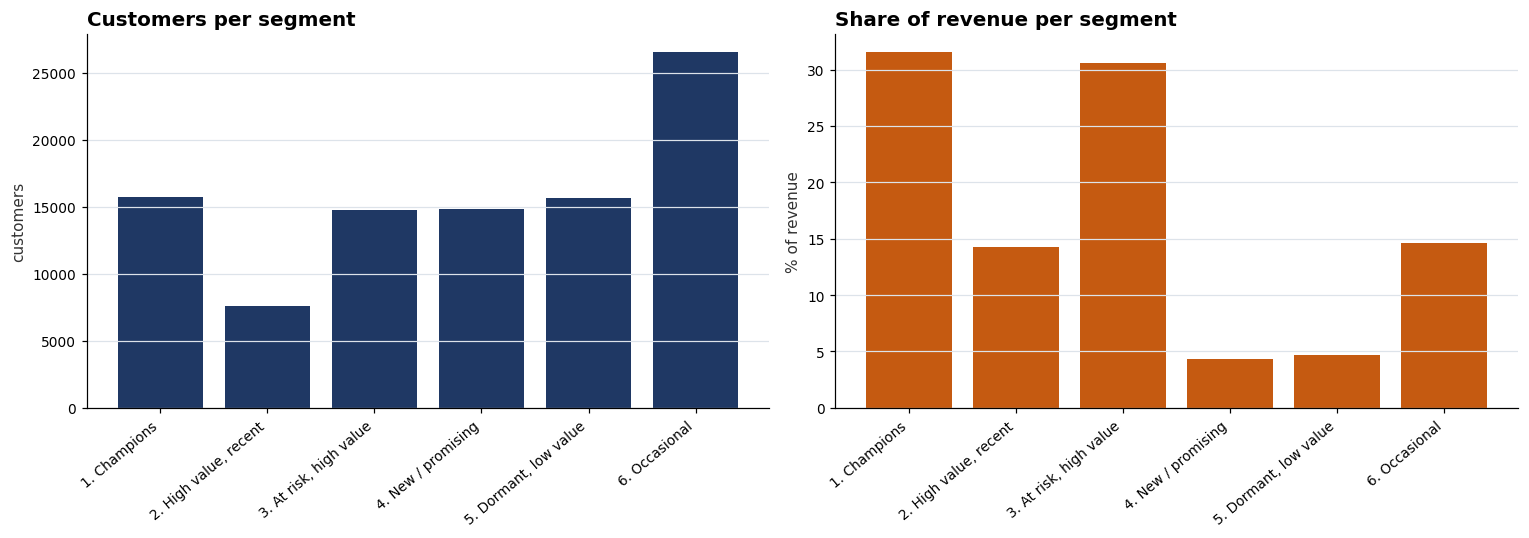

In [7]:
print(f"Recency baseline (dataset snapshot date): {SNAPSHOT_DATE}")

segments = q(f"""
    select
        rfm_segment,
        count(*)                                       as customers,
        round(avg(recency_days), 0)                    as avg_recency_days,
        round(avg(frequency), 2)                       as avg_frequency,
        round(avg(monetary), 2)                        as avg_monetary,
        round(sum(monetary), 0)                        as total_revenue,
        round(safe_divide(sum(monetary), sum(sum(monetary)) over ()), 4) as revenue_share,
        round(avg(late_rate), 4)                       as avg_late_rate,
        round(avg(avg_review_score), 2)                as avg_review_score,
        countif(is_high_value_with_late_delivery)      as high_value_served_late
    from {marts('agg_customer_rfm')}
    group by rfm_segment
    order by rfm_segment
""")
display(segments)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.bar(segments.rfm_segment, segments.customers, color="#1f3864")
ax1.set_title("Customers per segment"); ax1.set_ylabel("customers")
ax1.tick_params(axis="x", rotation=40)
ax2.bar(segments.rfm_segment, segments.revenue_share * 100, color="#c55a11")
ax2.set_title("Share of revenue per segment"); ax2.set_ylabel("% of revenue")
ax2.tick_params(axis="x", rotation=40)
for ax in (ax1, ax2):
    for label in ax.get_xticklabels():
        label.set_ha("right")
plt.tight_layout(); plt.show()

In [8]:
# Proof that the identity trap was avoided: if this were keyed on customer_id,
# every customer would have frequency exactly 1 and this table would be one row.
freq = q(f"""
    select frequency, count(*) as customers, round(sum(monetary), 0) as revenue
    from {marts('agg_customer_rfm')}
    group by frequency order by frequency
""")
display(freq.head(10))
repeat_share = freq[freq.frequency > 1].customers.sum() / freq.customers.sum()
print(f"Repeat customers: {repeat_share:.2%} of the base  -  small, but they exist,")
print("and they would all have been invisible if we had segmented on customer_id.")

,frequency,customers,revenue
0,1,92102,12743904.0
1,2,2652,650992.0
2,3,188,68111.0
3,4,29,19166.0
4,5,9,5617.0
5,6,5,2601.0
6,7,3,2280.0
7,9,1,1001.0
8,16,1,730.0


Repeat customers: 3.04% of the base  -  small, but they exist,
and they would all have been invisible if we had segmented on customer_id.


In [9]:
# The retention argument: how much high-value revenue is exposed to late delivery.
exposure = q(f"""
    select
        countif(is_high_value_with_late_delivery)                     as at_risk_customers,
        round(sum(case when is_high_value_with_late_delivery
                       then monetary end), 0)                         as at_risk_revenue,
        round(sum(monetary), 0)                                       as total_revenue,
        round(safe_divide(sum(case when is_high_value_with_late_delivery
                                   then monetary end), sum(monetary)), 4) as at_risk_share
    from {marts('agg_customer_rfm')}
""").iloc[0]

print(f"High-value customers who have experienced a late delivery: {exposure.at_risk_customers:,}")
print(f"Revenue they represent : R$ {exposure.at_risk_revenue:,.0f}")
print(f"Share of total revenue : {exposure.at_risk_share:.1%}")
print()
print("This is the number that turns a logistics metric into a retention budget.")

High-value customers who have experienced a late delivery: 2,868.0
Revenue they represent : R$ 822,182
Share of total revenue : 6.1%

This is the number that turns a logistics metric into a retention budget.


## 4. ReconciliationA final independent check that the marts numbers equal the staging numbers. The dbttest `assert_revenue_reconciles_staging_to_mart` already enforces this on everybuild; repeating it here means the notebook's own figures are demonstrably the sameones the pipeline tested.

In [10]:
recon = q(f"""
    select
        (select round(sum(item_price), 2) from {staging('stg_order_items')})  as staging_revenue,
        (select round(sum(item_price), 2) from {marts('fct_order_items')})    as fact_item_revenue,
        (select round(sum(order_revenue), 2) from {marts('fct_orders')})      as fact_order_revenue,
        (select count(distinct order_id) from {staging('stg_orders')})        as staging_orders,
        (select count(*) from {marts('fct_orders')})                          as fact_order_rows
""").iloc[0]

display(recon)
assert recon.staging_revenue == recon.fact_item_revenue == recon.fact_order_revenue, \
    "Revenue does not reconcile: a join has fanned out somewhere."
assert recon.staging_orders == recon.fact_order_rows, \
    "fct_orders is not at one row per order."
print("\nReconciliation PASSED: revenue and order counts match staging exactly.")

staging_revenue       13591643.7
fact_item_revenue     13591643.7
fact_order_revenue    13591643.7
staging_orders           99441.0
fact_order_rows          99441.0
Name: 0, dtype: float64


Reconciliation PASSED: revenue and order counts match staging exactly.


## Insight cards### Insight  -  Sales trend- **Observation:**- **Interpretation:**- **Decision:**- **Expected impact:**- **Caveat:** the first and last months of the export are partial and are excluded  from the trend, not evidence of a collapse.### Insight  -  Product mix- **Observation:**- **Interpretation:**- **Decision:**- **Expected impact:**- **Caveat:**### Insight  -  Customer segments- **Observation:**- **Interpretation:**- **Decision:**- **Expected impact:**- **Caveat:** Olist's base is overwhelmingly single-purchase, so frequency has little  spread and the segmentation leans on recency and monetary value.